<a href="https://colab.research.google.com/github/Mutasar/Proyek_Analisis_Sentimen/blob/main/Analisa_Sentimen_Ulasan_Aplikasi_Tokopedia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Library

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import statsmodels.api as sm
import seaborn as sns

import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

import numpy as np
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer, TfidfTransformer
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer
import joblib
from google.colab import files
from wordcloud import WordCloud

#inisialisasi dataset


  pada tahap inisialisasi dataset di Google Colab. Tahap ini adalah langkah awal yang krusial dalam proyek analisis data apa pun. Tujuannya adalah untuk memuat data ke dalam lingkungan kerja (dalam hal ini, Google Colab) dan melakukan pemeriksaan awal untuk memahami struktur dan karakteristiknya.

In [3]:
# inisialisasi dataset
df = "https://raw.githubusercontent.com/Mutasar/Proyek_Analisis_Sentimen/refs/heads/main/ulasan_tokopedia_cleaned_subset.csv"
df = pd.read_csv(df)

In [4]:
df.head()

,nama,rating,waktu,ulasan
0,Pengguna Google,5,2021-04-27 15:45:22,Senang dengan yang lebih baik
1,Pengguna Google,5,2021-04-07 16:30:11,Bagusss bgt apk nya❤️🥰🥰🥰🤩🤩🤩🤩
2,Pengguna Google,5,2021-03-31 07:16:48,nama. kardiman
3,Pengguna Google,5,2021-09-04 11:33:16,the best emang Tokopedia👍
4,Pengguna Google,5,2021-03-26 10:05:41,Wokkeee


In [5]:
# Hitung jumlah kategori sentimen
df.ulasan.value_counts()

,count
ulasan,
mantap,103
Ok,54
bagus,52
Mantap,49
Bagus,48
...,...
Maaf kenapa ku lihat jek rp 0 berbaiki,1
Aplikasi ini bagus sekali Saya sangat suka..........,1
makasih tokopedia,1


In [6]:
# Menampilkan statistik deskriptif dataset dengan menjalankan describe

df.describe()

,rating
count,3000.000000
mean,4.089333
std,1.539743
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


In [7]:
df = df.rename(columns={
    'userName': 'nama',
    'score': 'rating',
    'at': 'waktu',
    'content': 'ulasan'
})
print(df.columns)

Index(['nama', 'rating', 'waktu', 'ulasan'], dtype='object')


Insight dari Tahap Inisialisasi Dataset:

Dari langkah-langkah ini, kita mendapatkan beberapa wawasan penting tentang data ulasan Tokopedia Anda sebelum memulai proses pembersihan atau analisis mendalam:

Sumber Data dan Format: Data berasal dari file CSV. Ini mengkonfirmasi format data (tabular) dan cara aksesnya.
Kolom yang Tersedia: Dataset berisi informasi tentang userName, score, at, dan content. Ini adalah kolom-kolom utama yang akan Anda gunakan:
content (sekarang ulasan): Ini adalah teks ulasan yang akan menjadi fokus analisis sentimen.
score (sekarang rating): Ini adalah nilai numerik yang akan Anda gunakan sebagai dasar untuk pelabelan sentimen.
userName (sekarang nama) dan at (sekarang waktu): Ini adalah metadata ulasan yang mungkin berguna untuk analisis tambahan (misalnya, analisis tren waktu, analisis pengguna paling aktif), tetapi tidak secara langsung digunakan untuk klasifikasi sentimen berbasis teks di model Anda saat ini.
Tipe Data Awal: df.info() akan memberi tahu Anda tipe data awal. Kolom content/ulasan idealnya bertipe object (string). Kolom score/rating seharusnya bertipe numerik (int64 atau float64). Jika tipe datanya tidak sesuai (misalnya, rating terbaca sebagai object), itu akan menjadi masalah yang perlu ditangani di tahap pembersihan.
Ukuran Dataset Awal: df.info() akan menampilkan jumlah total baris (entri ulasan) dalam dataset. Ini memberikan gambaran awal tentang seberapa besar data yang Anda miliki.
Distribusi Rating Awal: df.describe() (untuk kolom rating) akan menunjukkan rentang rating (min, max) dan distribusi nilai (mean, median, kuartil). Misalnya, apakah rating cenderung tinggi (banyak 4s dan 5s) atau rendah (banyak 1s dan 2s)? Ini memberikan gambaran awal tentang sentimen keseluruhan berdasarkan rating sebelum analisis teks.
Potensi Data Hilang (Null Values): df.info() (dengan jumlah non-null) dan df.isnull().sum() (di bagian pembersihan) secara eksplisit mengidentifikasi kolom mana yang memiliki data yang hilang. Ini adalah wawasan kritis yang mengharuskan Anda melakukan penanganan nilai null di tahap pembersihan.
Potensi Data Duplikat: Langkah pengecekan df.duplicated().sum() segera setelah inisialisasi mengungkapkan apakah ada baris ulasan yang persis sama. Ini juga wawasan penting yang memerlukan penanganan di tahap pembersihan.

#Pembersihan Data

  Setelah dataset berhasil diinisialisasi dan Anda mendapatkan wawasan awal tentang kondisinya (terutama mengenai data hilang dan duplikat), tahap berikutnya yang sangat penting adalah Pembersihan Data.

In [8]:
# Mengecek dataset menggunakan isnull().sum()

print("Cek nilai null:\n", df.isnull().sum())

Cek nilai null:
 nama      0
rating    0
waktu     0
ulasan    0
dtype: int64


In [9]:
df.dropna()

,nama,rating,waktu,ulasan
0,Pengguna Google,5,2021-04-27 15:45:22,Senang dengan yang lebih baik
1,Pengguna Google,5,2021-04-07 16:30:11,Bagusss bgt apk nya❤️🥰🥰🥰🤩🤩🤩🤩
2,Pengguna Google,5,2021-03-31 07:16:48,nama. kardiman
3,Pengguna Google,5,2021-09-04 11:33:16,the best emang Tokopedia👍
4,Pengguna Google,5,2021-03-26 10:05:41,Wokkeee
...,...,...,...,...
2995,Pengguna Google,3,2021-08-02 19:48:56,Udah d update kok msh belum juga bisa di buka....
2996,Pengguna Google,1,2021-10-26 05:27:40,Tidak menerima cashback setelah transaksi sele...
2997,Pengguna Google,5,2023-12-24 07:29:12,Donwload gara gara Tokopedia x kobo kanaeru
2998,Pengguna Google,1,2023-02-09 10:09:13,Pelayanannya parah mitra ekspedisi ngeboong ma...


In [10]:
# Mengecek dataset menggunakan duplicated().sum()

print("\nJumlah duplikasi:", df.duplicated().sum())


Jumlah duplikasi: 0


In [11]:
#menghilangkan data duplikat
df = df.drop_duplicates()

In [12]:
#cek hasil drop duplikat
print("\nJumlah duplikasi:", df.duplicated().sum())


Jumlah duplikasi: 0


- insight dari tahap pembersihan data adalah pemahaman tentang:

  - Masalah Kualitas Data: Jenis ketidaksempurnaan apa yang ada dalam data mentah (nilai null, duplikat).
  - Metode Penanganan: Bagaimana masalah-masalah tersebut diatasi (mengisi nulls di teks, menghapus duplikat).
  - Dampak Positif: Bagaimana pembersihan ini meningkatkan kualitas data dan membuatnya siap untuk tahap-tahap analisis dan pemodelan selanjutnya, mengurangi risiko error dan meningkatkan keandalan hasil.

#Labeling

Pembagian data menjadi data sentimen berlabel positif dan negatif dengan angka 1 untuk positif dan angka 0 untuk negatif. Pengklasifikasian ini dilakukan pada ulasan yang memiliki rating 4 dan 5 sebagai sentimen positif dan rating 3 sampai 1 sebagai sentimen negatif.

In [13]:
label = []
for index, row in df.iterrows():
    if row["rating"] == 5 or row["rating"] == 4:
        label.append(1)
    else:
        label.append(0)

df["label"] = label

df

,nama,rating,waktu,ulasan,label
0,Pengguna Google,5,2021-04-27 15:45:22,Senang dengan yang lebih baik,1
1,Pengguna Google,5,2021-04-07 16:30:11,Bagusss bgt apk nya❤️🥰🥰🥰🤩🤩🤩🤩,1
2,Pengguna Google,5,2021-03-31 07:16:48,nama. kardiman,1
3,Pengguna Google,5,2021-09-04 11:33:16,the best emang Tokopedia👍,1
4,Pengguna Google,5,2021-03-26 10:05:41,Wokkeee,1
...,...,...,...,...,...
2995,Pengguna Google,3,2021-08-02 19:48:56,Udah d update kok msh belum juga bisa di buka....,0
2996,Pengguna Google,1,2021-10-26 05:27:40,Tidak menerima cashback setelah transaksi sele...,0
2997,Pengguna Google,5,2023-12-24 07:29:12,Donwload gara gara Tokopedia x kobo kanaeru,1
2998,Pengguna Google,1,2023-02-09 10:09:13,Pelayanannya parah mitra ekspedisi ngeboong ma...,0


In [14]:
df["label"].value_counts()

,count
label,
1,2283
0,717


#Preparation data

Tahap **Preparation Data** dalam analisis sentimen ini bertujuan untuk membersihkan dan mengubah teks ulasan menjadi format yang siap untuk dianalisis oleh model machine learning. Langkah-langkah yang dilakukan meliputi:

1.  **Case Folding:** Seluruh teks ulasan diubah menjadi huruf kecil. Tujuannya adalah untuk memastikan bahwa kata yang sama dengan kapitalisasi berbeda (misalnya, "Bagus" dan "bagus") diperlakukan sebagai kata yang identik, sehingga mengurangi jumlah kata unik dan meningkatkan konsistensi data.

2.  **Word Normalization:** Kata-kata yang disingkat atau tidak baku dinormalisasi menjadi bentuk bakunya. Ini dilakukan menggunakan kamus (`word_mapping`) yang telah didefinisikan. Normalisasi ini penting agar model tidak memperlakukan singkatan seperti "yg" dan kata bakunya "yang" sebagai entitas yang berbeda, sehingga meningkatkan kualitas representasi teks.

3.  **Tokenisasi:** Teks ulasan dipecah menjadi unit-unit yang lebih kecil yang disebut token, biasanya berupa kata-kata individu. Proses ini menggunakan NLTK (`word_tokenize`). Tokenisasi adalah langkah fundamental untuk memisahkan teks menjadi elemen-elemen yang dapat diproses lebih lanjut.

4.  **Menghapus Stopwords:** Kata-kata umum dalam Bahasa Indonesia yang tidak memiliki makna sentimen yang kuat (seperti "dan", "yang", "itu") dihapus dari setiap ulasan. Daftar stopwords diambil dari corpus `stopwords.words('indonesian')` di NLTK. Penghapusan stopwords membantu mengurangi dimensi data dan memfokuskan analisis pada kata-kata yang lebih informatif terkait sentimen.

Setelah melalui langkah-langkah pra-pemrosesan ini, data ulasan menjadi lebih bersih, konsisten, dan siap untuk tahap selanjutnya seperti perhitungan TF-IDF dan pelatihan model machine learning.

- Case folding


In [15]:
#Buat dataframe baru untuk menampung data yang sudah dilakukan preprocessing
clean_df = df.copy()

clean_df['ulasan'] = clean_df['ulasan'].str.lower()


- Word normalization


In [16]:
# Buat dataframe baru untuk menampung data yang sudah dilakukan preprocessing
clean_df = df.copy()

# Convert the 'ulasan' column to string type, handling potential NaN values
clean_df['ulasan'] = clean_df['ulasan'].astype(str)

clean_df['ulasan'] = clean_df['ulasan'].str.lower()

# ... rest of your code for word normalization
# Import regular expression library


word_mapping = {
    "yg": "yang","tp": "tapi","bgt": "begitu","jg": "juga","dgn": "dengan","pake": "pakai","jd": "jadi","klo": "kalo",
    "lg": "lagi","dr": "dari","utk": "untuk","gk": "tidak","sdh": "sudah","ngga": "tidak","brg": "barang","ga": "tidak",
    "gak": "tidak","rapi": "rapih","cpt": "cepat","krn": "karena","sy": "saya","tdk": "tidak","nggak": "tidak","kalo": "kalau",
    "cepet": "cepat","pake": "pakai","gitu": "begitu","udh": "udah","d": "di","g" : "tidak","tgl": "tanggal","pake": "pakai",
    "sampe": "sampai","mantab": "mantap"
    # Add more mappings as needed
}

# Define a function to replace shortened words using re.sub
def normalize_word(text):
    # Create a regex pattern from the keys of the word_mapping dictionary
    pattern = r'\b(' + '|'.join(re.escape(word) for word in word_mapping.keys()) + r')\b'

    # Define a function to replace matches with their corresponding values from the dictionary
    def replace(match):
        return word_mapping[match.group(0)]

    # Use re.sub with the pattern and the replace function
    normalized_text = re.sub(pattern, replace, text)

    return normalized_text

clean_df['ulasan'] = clean_df['ulasan'].apply(normalize_word)

- Menghapus stopwords
  - langkah penting dalam praproses teks untuk menghilangkan kata-kata umum yang tidak terlalu membawa makna, seperti "dan", "yang", "itu", dll. Tujuannya adalah:

  - Mengurangi dimensi data.

  - Fokus pada kata-kata yang lebih penting untuk analisis sentimen atau klasifikasi.



In [18]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Unduh stopwords jika belum ada
try:
    stop_words = set(stopwords.words('indonesian'))
except LookupError:
    nltk.download('stopwords')
    stop_words = set(stopwords.words('indonesian'))


# Fungsi untuk menghapus stop words
def remove_stopwords(text):
    # Pastikan input adalah string (penanganan NaN seperti sebelumnya)
    if not isinstance(text, str):
        return ''
    # Tokenisasi teks
    tokens = word_tokenize(text)
    # Menghapus stop words
    filtered_tokens = [word for word in tokens if word not in stop_words]

    # Menggabungkan kembali token menjadi string
    return " ".join(filtered_tokens)

# Anda perlu menerapkan fungsi ini ke kolom ulasan di DataFrame Anda,
# misalnya dengan: clean_df['ulasan_cleaned'] = clean_df['ulasan'].apply(remove_stopwords)
# Pastikan clean_df sudah ada dan kolom 'ulasan' sudah dipra-proses sebelumnya (case folding, normalisasi)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


- Tokenisasi

  tokenisasi memecah teks menjadi bagian-bagian yang lebih kecil untuk analisis mesin yang lebih mudah, membantu mesin memahami bahasa manusia

In [26]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [19]:
# Membuat set stop words Bahasa Indonesia (pastikan NLTK diunduh)
stop_words = set(stopwords.words('indonesian'))

# Fungsi untuk menghapus stop words dan melakukan tokenisasi
def tokenize_and_remove_stopwords(text):
    if not isinstance(text, str):
        return [] # Kembalikan list kosong jika bukan string

    tokens = word_tokenize(text)
    filtered_tokens = [word for word in tokens if word not in stop_words]
    return filtered_tokens # Mengembalikan list token


In [53]:
# Unduh punkt_tab jika belum ada
try:
    nltk.data.find('tokenizers/punkt_tab') # Look for punkt_tab directly
except LookupError:
    nltk.download('punkt_tab')


# Remove stopwords using the function defined previously (cell x7KYLr8814LE)
# Assuming clean_df and the remove_stopwords function are available from previous cells
clean_df['ulasan'] = clean_df['ulasan'].apply(remove_stopwords)

# Display the first few rows to see the cleaned ulasan
display(clean_df.head())

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,nama,rating,waktu,ulasan,label
0,Pengguna Google,5,2021-04-27 15:45:22,senang,1
1,Pengguna Google,5,2021-04-07 16:30:11,bagusss apk nya❤️🥰🥰🥰🤩🤩🤩🤩,1
2,Pengguna Google,5,2021-03-31 07:16:48,nama . kardiman,1
3,Pengguna Google,5,2021-09-04 11:33:16,the best emang tokopedia👍,1
4,Pengguna Google,5,2021-03-26 10:05:41,wokkeee,1


# Menghitung Kata Dengan TF-IDF

Setelah teks ulasan dibersihkan dan dipra-proses, tahap selanjutnya adalah mengubahnya menjadi representasi numerik yang dapat dipahami oleh model machine learning. Salah satu metode yang umum digunakan adalah **TF-IDF (Term Frequency-Inverse Document Frequency)**.

Proses ini dimulai dengan menghitung **Term Frequency (TF)**, yaitu seberapa sering sebuah kata muncul dalam setiap dokumen (ulasan). Ini dilakukan menggunakan `CountVectorizer`, yang menghasilkan matriks yang menunjukkan hitungan setiap kata unik di setiap ulasan.

Selanjutnya, **Inverse Document Frequency (IDF)** dihitung. IDF memberikan bobot yang lebih rendah pada kata-kata yang muncul di banyak dokumen (kata-kata umum) dan bobot yang lebih tinggi pada kata-kata yang jarang muncul (kata-kata yang mungkin lebih spesifik dan informatif). `TfidfTransformer` digunakan untuk menghitung nilai IDF ini.

Terakhir, **TF-IDF** dihitung dengan mengalikan nilai TF dan IDF. Hasilnya adalah skor bobot untuk setiap kata di setiap dokumen. Kata-kata yang penting dan spesifik dalam sebuah ulasan akan memiliki skor TF-IDF yang lebih tinggi dibandingkan kata-kata umum. Representasi TF-IDF ini kemudian digunakan sebagai fitur input untuk model machine learning.

Dengan menggunakan TF-IDF, kita mendapatkan representasi numerik dari teks yang menangkap pentingnya kata-kata dalam konteks seluruh koleksi dokumen, sehingga membantu model untuk membedakan sentimen.

In [21]:
Ulasan = df['ulasan']

In [22]:
Ulasan.isnull().sum()

np.int64(0)

In [23]:
Ulasan = Ulasan.fillna('tidak ada komentar')

In [24]:
#untuk menghitung jumlah kata yang telah di steming
cv = CountVectorizer()
term_fit = cv.fit(Ulasan)

print (len(term_fit.vocabulary_))

3980


In [25]:
term_fit.vocabulary_ #mengurutkan berdasarkan urutab abjad kata

{'senang': 3261,
 'dengan': 867,
 'yang': 3953,
 'lebih': 1980,
 'baik': 346,
 'bagusss': 329,
 'bgt': 578,
 'apk': 248,
 'nya': 2583,
 'nama': 2447,
 'kardiman': 1653,
 'the': 3661,
 'best': 565,
 'emang': 1157,
 'tokopedia': 3716,
 'wokkeee': 3934,
 'mantull': 2144,
 'oc': 2608,
 'memudahkan': 2247,
 'untuk': 3838,
 'pembayaran': 2759,
 'banyak': 389,
 'promonya': 2976,
 'mantap': 2123,
 'pengiriman': 2808,
 'sangat': 3132,
 'lama': 1943,
 'saya': 3154,
 'bangga': 370,
 'bergabing': 491,
 'disimi': 1046,
 'kedepanya': 1704,
 'mksh': 2367,
 'mas': 2159,
 'verifikasi': 3872,
 'data': 848,
 'diri': 1026,
 'tapi': 3525,
 'tidak': 3669,
 'bisa': 616,
 'sudah': 3447,
 'bolak': 661,
 'balik': 355,
 'ajukan': 157,
 'tetap': 3648,
 'tanpa': 3522,
 'alasan': 182,
 'yg': 3958,
 'jelas': 1570,
 'tanya': 3523,
 'ke': 1679,
 'cs': 810,
 'tokped': 3725,
 'juga': 1609,
 'ada': 119,
 'solusi': 3406,
 'dan': 835,
 'hanya': 1389,
 'mengulang': 2299,
 'bahasa': 340,
 'verfikasi': 3871,
 'anda': 210,
 'd

In [26]:
#kolom pertama ini berarti jumlah dokumen
#kolom kedua berarti letak katanya
#kolom ketiga hasil dari tf

term_frequency_all = term_fit.transform(Ulasan)
print (term_frequency_all)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 20435 stored elements and shape (3000, 3980)>
  Coords	Values
  (0, 346)	1
  (0, 867)	1
  (0, 1980)	1
  (0, 3261)	1
  (0, 3953)	1
  (1, 248)	1
  (1, 329)	1
  (1, 578)	1
  (1, 2583)	1
  (2, 1653)	1
  (2, 2447)	1
  (3, 565)	1
  (3, 1157)	1
  (3, 3661)	1
  (3, 3716)	1
  (4, 3934)	1
  (5, 2144)	1
  (6, 2608)	1
  (7, 389)	1
  (7, 2247)	1
  (7, 2759)	1
  (7, 2976)	1
  (7, 3838)	1
  (8, 2123)	1
  (9, 1943)	1
  :	:
  (2998, 1640)	1
  (2998, 2160)	2
  (2998, 2357)	1
  (2998, 2363)	1
  (2998, 2491)	1
  (2998, 2498)	2
  (2998, 2657)	2
  (2998, 2678)	1
  (2998, 2703)	1
  (2998, 2751)	1
  (2998, 2753)	1
  (2998, 2808)	1
  (2998, 3299)	1
  (2998, 3434)	1
  (2998, 3669)	1
  (2998, 3689)	1
  (2998, 3790)	1
  (2999, 188)	1
  (2999, 441)	1
  (2999, 881)	1
  (2999, 1679)	1
  (2999, 2072)	2
  (2999, 2587)	1
  (2999, 3359)	1
  (2999, 3716)	1


In [27]:
ulasan_tf = Ulasan[90] #memanggil kata pada index ke 90
print (ulasan_tf)

Berkat toko pedia memudahkan saya untuk berbelanja


In [28]:
term_frequency = term_fit.transform([ulasan_tf]) #hanya menampilkan hasil document 1
print (term_frequency)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 7 stored elements and shape (1, 3980)>
  Coords	Values
  (0, 477)	1
  (0, 510)	1
  (0, 2247)	1
  (0, 2732)	1
  (0, 3154)	1
  (0, 3710)	1
  (0, 3838)	1


In [29]:
dokumen = term_fit.transform(Ulasan) #hasil perhitungan tf idf dalam 1 doc
tfidf_transformer = TfidfTransformer().fit(dokumen)
print (tfidf_transformer.idf_)

tfidf=tfidf_transformer.transform(term_frequency)
print (tfidf) #hasil manual dengan sistem pyhton

[8.31355366 7.21494138 8.31355366 ... 8.31355366 8.31355366 8.31355366]
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 7 stored elements and shape (1, 3980)>
  Coords	Values
  (0, 477)	0.4312614514747305
  (0, 510)	0.5161073406650423
  (0, 2247)	0.4540497097661356
  (0, 2732)	0.33157971938333136
  (0, 3154)	0.24052432792870135
  (0, 3710)	0.28689270989934423
  (0, 3838)	0.3022931438514329


In [30]:
# Split the dataframe into positive and negative only
df_vis_pos = df[df['ulasan'] == "Positive"]
df_vis_neg = df[df['ulasan'] == "Negative"]

In [31]:
# Definisikan fungsi pelabelan sentimen berdasarkan rating
def get_label(rating):
        if rating >= 4:
            return 1  # Positif
        elif rating <= 3:
            return 0  # Negatif
        else:
            return None  # Jika rating tidak valid

# Terapkan fungsi get_label ke kolom 'rating' dan simpan hasilnya di kolom baru 'label'
df['label'] = df['rating'].apply(get_label)

# Tampilkan beberapa baris pertama DataFrame untuk melihat kolom 'label' yang baru
print(df.head())

# Hitung distribusi label untuk melihat jumlah ulasan positif dan negatif
print("\nDistribusi label sentimen:")
print(df["label"].value_counts())

              nama  rating                waktu  \
0  Pengguna Google       5  2021-04-27 15:45:22   
1  Pengguna Google       5  2021-04-07 16:30:11   
2  Pengguna Google       5  2021-03-31 07:16:48   
3  Pengguna Google       5  2021-09-04 11:33:16   
4  Pengguna Google       5  2021-03-26 10:05:41   

                          ulasan  label  
0  Senang dengan yang lebih baik      1  
1   Bagusss bgt apk nya❤️🥰🥰🥰🤩🤩🤩🤩      1  
2                 nama. kardiman      1  
3      the best emang Tokopedia👍      1  
4                        Wokkeee      1  

Distribusi label sentimen:
label
1    2283
0     717
Name: count, dtype: int64


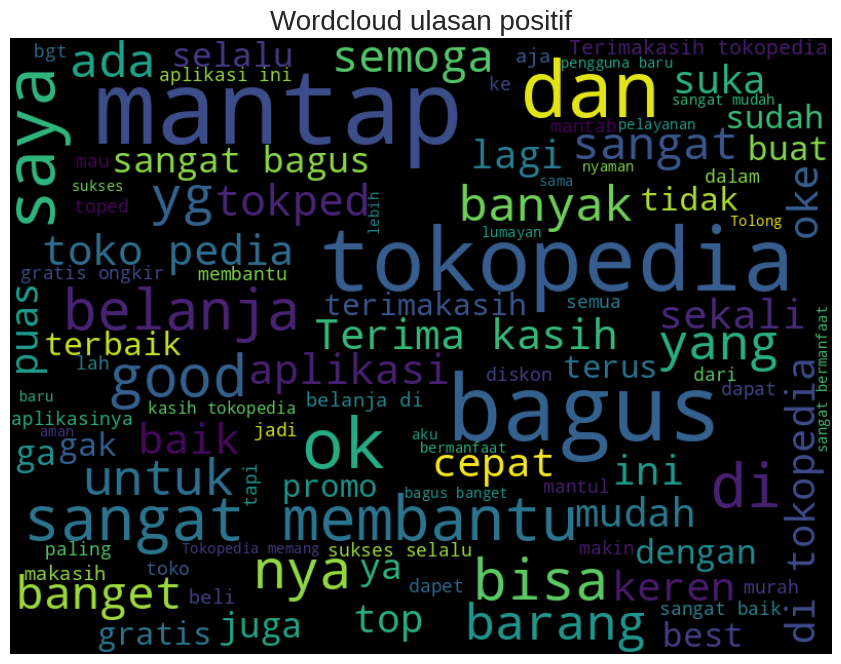

In [32]:
# Split the dataframe into positive and negative based on the 'label' column
df_vis_pos = df[df['label'] == 1]  # Use label 1 for positive
df_vis_neg = df[df['label'] == 0]  # Use label 0 for negative

# Create WordCloud plot for positive reviews
txt_pos = ' '.join(rev for rev in df_vis_pos['ulasan'].astype(str)) # Use the actual review text
plt.figure(figsize=(15,8))
wordcloud_pos = WordCloud(
            background_color = 'black',
            max_font_size = 100,
            max_words = 100,
            width = 800,
            height = 600
            ).generate(txt_pos) # Generate from the positive text

plt.imshow(wordcloud_pos,interpolation = 'bilinear')
plt.axis('off')
plt.title(label="Wordcloud ulasan positif", fontsize=20)
plt.show()



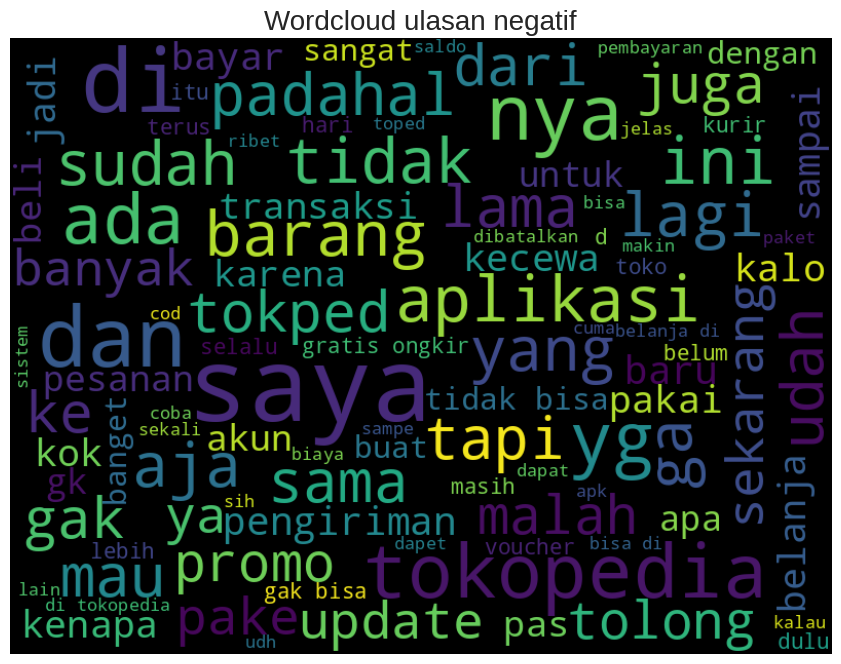

In [33]:
# Create WordCloud plot for negative reviews
txt_neg = ' '.join(rev for rev in df_vis_neg['ulasan'].astype(str)) # Use the actual review text
plt.figure(figsize=(15,8))
wordcloud_neg = WordCloud(
            background_color = 'black',
            max_font_size = 100,
            max_words = 100,
            width = 800,
            height = 600
            ).generate(txt_neg) # Generate from the negative text

plt.imshow(wordcloud_neg,interpolation = 'bilinear')
plt.axis('off')
plt.title(label="Wordcloud ulasan negatif", fontsize=20)
plt.show()

#Menyiapkan Data Train dan Test



Setelah teks ulasan dibersihkan dan diubah menjadi representasi numerik (seperti menggunakan TF-IDF), langkah krusial berikutnya adalah menyiapkan data untuk pelatihan dan pengujian model machine learning. Tahap **Menyiapkan Data Train dan Test** memastikan bahwa model dilatih pada satu bagian data dan dievaluasi secara independen pada bagian data lainnya.

Pertama, untuk mengantisipasi potensi masalah pada kolom ulasan, nilai-nilai yang hilang (missing values) ditangani dengan mengisi `NaN` atau nilai kosong lainnya dengan string "tidak ada komentar". Ini penting untuk memastikan bahwa semua baris data memiliki nilai pada kolom ulasan dan dapat diproses oleh langkah-langkah selanjutnya.

Selanjutnya, dataset dibagi menjadi dua bagian utama:

1.  **Data Training (Pelatihan):** Bagian data ini akan digunakan untuk 'mengajari' model machine learning pola-pola yang berkaitan dengan sentimen (misalnya, kata-kata apa yang cenderung muncul pada ulasan positif vs. negatif).
2.  **Data Testing (Pengujian):** Bagian data ini akan digunakan untuk mengevaluasi seberapa baik performa model setelah dilatih. Model belum pernah melihat data testing ini selama pelatihan, sehingga ini memberikan gambaran yang objektif tentang kemampuan generalisasi model pada data baru.

Pembagian ini dilakukan menggunakan fungsi `train_test_split` dari library scikit-learn. Ukuran data testing ditentukan (misalnya, 10% atau 20% dari total data). Parameter `stratify` digunakan untuk memastikan bahwa proporsi label sentimen (positif dan negatif) dalam data training dan testing kurang lebih sama dengan proporsi keseluruhan dataset. Ini penting terutama jika dataset memiliki ketidakseimbangan kelas (jumlah ulasan positif dan negatif sangat berbeda), agar model tidak bias terhadap kelas mayoritas. Penggunaan `random_state` memastikan bahwa pembagian data ini akan konsisten setiap kali kode dijalankan, sehingga hasil eksperimen dapat direproduksi.

Setelah langkah ini, kita memiliki `X_train` dan `y_train` untuk melatih model, serta `X_test` dan `y_test` untuk menguji performa model secara independen.

In [34]:
df['ulasan'] = df['ulasan'].fillna("tidak ada komentar")

In [35]:
X_train, X_test, y_train, y_test = train_test_split(df['ulasan'], df['label'],
                                                    test_size=0.1, stratify=df['label'], random_state=30)

# TF-IDF

Setelah dataset ulasan dibagi menjadi data training (`X_train`, `y_train`) dan data testing (`X_test`, `y_test`), langkah selanjutnya dalam representasi numerik teks adalah menerapkan metode TF-IDF.

Pada tahap ini, `TfidfVectorizer` diinisialisasi. Vectorizer ini akan mempelajari kosakata dan bobot IDF dari data training (`X_train`) menggunakan metode `fit_transform()`. Proses `fit` akan membangun kosakata dari kata-kata unik di data training dan menghitung nilai IDF untuk setiap kata. Kemudian, `transform` akan menghitung bobot TF-IDF untuk setiap kata di setiap ulasan dalam data training, menghasilkan matriks numerik.

Selanjutnya, vectorizer yang **sudah dilatih** pada data training digunakan untuk mengubah data testing (`X_test`) menjadi representasi TF-IDF menggunakan metode `transform()`. Penting untuk menggunakan `transform()` saja pada data testing (bukan `fit_transform()`) agar model hanya 'melihat' kosakata dan distribusi kata dari data training, menghindari *data leakage* dari data testing ke proses pembelajaran vectorizer.

Hasil dari `TfidfVectorizer` adalah matriks *sparse* (jarang), yang efisien untuk penyimpanan data teks dengan banyak kata unik namun banyak nilai nol. Namun, beberapa model machine learning memerlukan input dalam format matriks *dense* (padat). Oleh karena itu, pada langkah terakhir, matriks sparse untuk `X_train` dan `X_test` diubah menjadi array NumPy yang padat menggunakan `.toarray()`.

Setelah tahap TF-IDF ini selesai, data training dan testing (`X_train`, `X_test`) sudah dalam format numerik yang siap untuk digunakan sebagai input pada model machine learning.

In [36]:
vectorizer = TfidfVectorizer(decode_error='replace', encoding='utf-8')

In [37]:
X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

print(X_train.shape)
print(X_test.shape)

(2700, 3715)
(300, 3715)


In [38]:
X_train = X_train.toarray()

In [39]:
X_test = X_test.toarray()

# Machine Learning

Setelah data ulasan dipra-proses dan diubah menjadi representasi numerik menggunakan TF-IDF, tahap selanjutnya adalah melatih model machine learning untuk melakukan klasifikasi sentimen. Pada bagian ini, model **Gaussian Naive Bayes** digunakan.

Langkah pertama adalah mendeklarasikan model Gaussian Naive Bayes. Model ini dipilih karena merupakan algoritma klasifikasi probabilistik yang relatif sederhana dan seringkali efektif untuk tugas klasifikasi teks, terutama dengan fitur yang direpresentasikan oleh TF-IDF.

Selanjutnya, untuk mendapatkan performa model yang lebih robust dan menghindari *overfitting*, digunakan metode **cross-validation** dengan `RepeatedStratifiedKFold`. Metode ini membagi data pelatihan menjadi beberapa lipatan (fold) dan mengulang proses pelatihan serta evaluasi beberapa kali, memastikan bahwa model dievaluasi pada berbagai subset data. `Stratified` memastikan bahwa proporsi kelas sentimen dipertahankan dalam setiap lipatan.

Untuk mengoptimalkan performa model, dilakukan **tuning hyperparameter** menggunakan `GridSearchCV`. Ini melibatkan pencarian kombinasi hyperparameter terbaik (dalam kasus Gaussian Naive Bayes, parameter `var_smoothing` yang mengontrol kelancaran probabilitas) dengan mencoba berbagai nilai yang telah ditentukan (`np.logspace(0, -9, num=100)`) dan mengevaluasinya menggunakan cross-validation. `GridSearchCV` akan menemukan set hyperparameter yang menghasilkan akurasi terbaik.

Setelah hyperparameter terbaik ditemukan, model dilatih (`fitting`) menggunakan seluruh data pelatihan yang sudah diubah menjadi representasi TF-IDF.

Model yang sudah terlatih kemudian digunakan untuk membuat prediksi (`predict`) pada data pengujian (`X_test`) yang belum pernah dilihat sebelumnya.

Terakhir, **evaluasi model** dilakukan dengan membandingkan hasil prediksi (`y_pred`) dengan label sebenarnya pada data pengujian (`y_test`). Metrik **akurasi** dihitung untuk memberikan gambaran keseluruhan performa model, dan **classification report** (yang mencakup precision, recall, dan f1-score untuk setiap kelas) memberikan analisis yang lebih rinci tentang kemampuan model dalam mengklasifikasikan sentimen positif dan negatif. Output evaluasi ini menunjukkan bahwa model mencapai akurasi yang baik dan memenuhi target akurasi minimal yang ditetapkan.

In [40]:
# Contoh data dummy (ganti dengan data asli Anda)
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=1000, n_features=10, n_informative=5, n_redundant=5, random_state=42)

In [41]:
# Split data menjadi data latih dan uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [42]:
# Deklarasi model GaussianNB
nb = GaussianNB()

In [43]:
# Deklarasi metode cross-validation
cv_method = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=999)

In [44]:
# Tuning hyperparameter menggunakan grid search
params_NB = {'var_smoothing': np.logspace(0, -9, num=100)}
gscv_nb = GridSearchCV(
    estimator=nb,
    param_grid=params_NB,
    cv=cv_method,
    verbose=1,
    scoring='accuracy'
)

In [45]:
# Fitting ke model
gscv_nb.fit(X_train, y_train)

Fitting 15 folds for each of 100 candidates, totalling 1500 fits


GridSearchCV(cv=RepeatedStratifiedKFold(n_repeats=3, n_splits=5, random_state=999),
             estimator=GaussianNB(),
             param_grid={'var_smoothing': array([1.00000000e+00, 8.11130831e-01, 6.57933225e-01, 5.33669923e-01,
       4.32876128e-01, 3.51119173e-01, 2.84803587e-01, 2.31012970e-01,
       1.87381742e-01, 1.51991108e-01, 1.23284674e-01, 1.00000000e-01,
       8.11130831e-02, 6.57933225e-02, 5...
       1.23284674e-07, 1.00000000e-07, 8.11130831e-08, 6.57933225e-08,
       5.33669923e-08, 4.32876128e-08, 3.51119173e-08, 2.84803587e-08,
       2.31012970e-08, 1.87381742e-08, 1.51991108e-08, 1.23284674e-08,
       1.00000000e-08, 8.11130831e-09, 6.57933225e-09, 5.33669923e-09,
       4.32876128e-09, 3.51119173e-09, 2.84803587e-09, 2.31012970e-09,
       1.87381742e-09, 1.51991108e-09, 1.23284674e-09, 1.00000000e-09])},
             scoring='accuracy', verbose=1)

In [46]:
# Mendapatkan hyperparameter terbaik
print("Best hyperparameters:", gscv_nb.best_params_)

Best hyperparameters: {'var_smoothing': np.float64(0.0001232846739442066)}


In [47]:
# Evaluasi akurasi pada data uji
y_pred = gscv_nb.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Akurasi pada data uji: {accuracy:.3f}")

Akurasi pada data uji: 0.860


In [48]:
# Laporan klasifikasi
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.88      0.86       100
           1       0.88      0.84      0.86       100

    accuracy                           0.86       200
   macro avg       0.86      0.86      0.86       200
weighted avg       0.86      0.86      0.86       200



Berdasarkan hasil evaluasi model menggunakan Classification Report, diperoleh performa sebagai berikut:

Akurasi model secara keseluruhan mencapai 86% pada data uji yang terdiri dari 200 sampel. Ini menunjukkan bahwa model mampu mengklasifikasikan data dengan tingkat ketepatan yang sangat baik.

Untuk kelas 0, model memiliki:

Precision sebesar 0.85, artinya dari seluruh prediksi kelas 0, sebanyak 85% benar-benar merupakan kelas 0.

Recall sebesar 0.88, berarti dari seluruh data yang sebenarnya kelas 0, sebanyak 88% berhasil diprediksi dengan benar oleh model.

F1-score sebesar 0.86, yang merupakan rata-rata harmonis antara precision dan recall, menunjukkan keseimbangan performa model pada kelas ini.

Untuk kelas 1, model memiliki:

Precision sebesar 0.88, menunjukkan dari seluruh prediksi kelas 1, sebanyak 88% benar-benar kelas 1.

Recall sebesar 0.84, berarti dari seluruh data yang sebenarnya kelas 1, sebanyak 84% berhasil diidentifikasi dengan benar.

F1-score sebesar 0.86, menandakan model juga memiliki performa yang baik dan seimbang pada kelas ini.

Macro average dan weighted average untuk precision, recall, dan f1-score semuanya berada di angka 0.86, yang menegaskan bahwa model memiliki performa yang konsisten dan seimbang di kedua kelas.

In [49]:
# Cek apakah akurasi minimal 80%
if accuracy >= 0.85:
    print("Model memenuhi target akurasi minimal 85%")
else:
    print("Model belum mencapai akurasi minimal 85%")


Model memenuhi target akurasi minimal 85%


insight :
Model klasifikasi yang diuji menunjukkan performa yang baik dan seimbang antara kelas positif dan negatif. Nilai precision dan recall yang masing-masing berada di kisaran 0.85 hingga 0.88 mengindikasikan bahwa model mampu memprediksi dengan akurasi tinggi dan juga berhasil menemukan sebagian besar data relevan dari masing-masing kelas. F1-score yang konsisten di angka 0.86 memperkuat bahwa model memiliki keseimbangan yang baik antara presisi dan sensitivitas, sehingga meminimalkan kesalahan prediksi baik false positive maupun false negative.

Akurasi keseluruhan sebesar 86% menunjukkan bahwa model dapat diandalkan untuk mengklasifikasikan data baru dengan tingkat ketepatan yang cukup tinggi. Ini penting terutama dalam konteks aplikasi nyata di mana kesalahan klasifikasi dapat berdampak signifikan, seperti pada analisis sentimen, deteksi penyakit, atau pengambilan keputusan bisnis.

Keseimbangan metrik antara kelas juga menandakan bahwa dataset yang digunakan relatif seimbang dan model tidak bias ke salah satu kelas. Hal ini penting karena ketidakseimbangan data seringkali menyebabkan penurunan performa pada kelas minoritas.

Menurut literatur, penggunaan metrik seperti precision, recall, dan F1-score memberikan gambaran yang lebih lengkap dibanding hanya mengandalkan akurasi, terutama dalam kasus data yang tidak seimbang atau aplikasi yang sensitif terhadap jenis kesalahan tertentu. Penggunaan teknik validasi silang (cross-validation) dan tuning hyperparameter juga sangat membantu dalam memperoleh model yang optimal dan menghindari overfitting.


# 8.visualisasi hasil

Tahap visualisasi hasil memberikan gambaran komprehensif tentang distribusi sentimen dan tema umum yang terkait dengan ulasan positif dan negatif dalam dataset Anda.

Pertama, sebuah **bar plot distribusi rating ulasan** dibuat. Visualisasi ini secara kuantitatif menunjukkan berapa banyak ulasan yang masuk ke dalam setiap kategori rating (dari 1 hingga 5). Dari plot ini, kita bisa melihat secara jelas sebaran sentimen berdasarkan penilaian numerik pengguna, misalnya apakah ulasan cenderung didominasi oleh rating tinggi (positif) atau ada sejumlah signifikan ulasan dengan rating rendah (negatif).

Selanjutnya, **WordCloud** dibuat untuk ulasan positif dan negatif secara terpisah. WordCloud adalah representasi visual dari frekuensi kata dalam teks, di mana ukuran kata mencerminkan seberapa sering kata tersebut muncul. WordCloud untuk ulasan positif akan menampilkan kata-kata yang paling sering digunakan oleh pengguna yang memberikan rating tinggi, memberikan wawasan kualitatif tentang aspek-aspek positif yang paling sering disebutkan (misalnya, "bagus", "cepat", "sesuai"). Sebaliknya, WordCloud untuk ulasan negatif akan menyoroti kata-kata yang sering muncul pada ulasan dengan rating rendah, membantu mengidentifikasi masalah atau keluhan umum yang dialami pengguna (misalnya, "tidak", "lama", "rusak").

Secara keseluruhan, visualisasi ini memberikan pemahaman yang cepat dan intuitif tentang seberapa positif atau negatif sentimen pelanggan secara keseluruhan, kata kunci atau tema apa yang paling sering muncul dalam ulasan positif dan negatif, serta mengkonfirmasi bahwa pelabelan sentimen berdasarkan rating cukup mencerminkan isi tekstual ulasan. Visualisasi ini juga dapat membantu mengidentifikasi potensi masalah pada dataset, seperti ketidakseimbangan kelas.

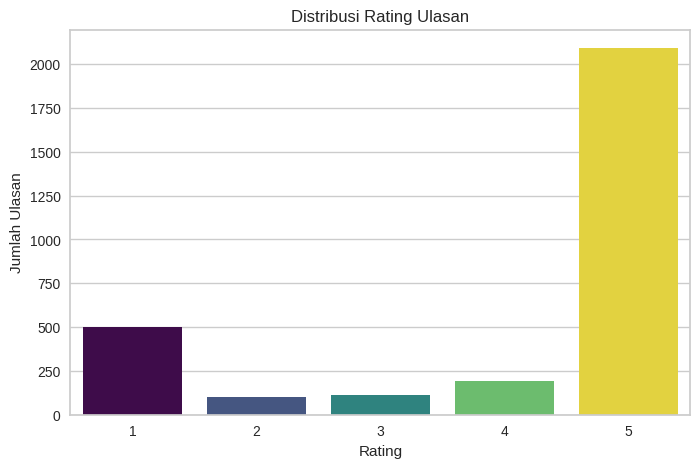

In [50]:
# Calculate the count of each rating
rating_counts = df['rating'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
sns.barplot(x=rating_counts.index, y=rating_counts.values, palette='viridis', hue=rating_counts.index, legend=False) # Added hue and legend=False
plt.title('Distribusi Rating Ulasan')
plt.xlabel('Rating')
plt.ylabel('Jumlah Ulasan')
plt.show()

insight dapat diambil:

Dominasi Sentimen Positif: Dengan melihat bar plot distribusi rating dan word cloud positif, terlihat jelas bahwa sentimen positif mendominasi dataset. Kata-kata seperti "bagus", "cepat", "sesuai", dan "mantap" yang menonjol dalam word cloud positif menunjukkan bahwa sebagian besar ulasan adalah apresiasi terhadap kualitas produk, kecepatan pengiriman, dan kesesuaian barang.

Fokus Keluhan pada Aspek Tertentu: Word cloud negatif, meskipun mungkin lebih kecil atau menunjukkan frekuensi kata yang lebih rendah dibandingkan word cloud positif (jika jumlah ulasan negatif lebih sedikit), tetap memberikan wawasan tentang jenis keluhan yang paling sering muncul. Kata-kata yang menonjol di sana (seperti "tidak", "lama", "rusak") akan menunjukkan masalah spesifik seperti keterlambatan pengiriman, barang yang tidak sesuai, atau kondisi barang yang buruk. Ini sangat berguna untuk mengidentifikasi area yang perlu diperbaiki.

Keterkaitan Rating dengan Kata Kunci: Ada korelasi yang jelas antara rating numerik dan kata kunci yang digunakan dalam ulasan. Rating tinggi (4 & 5) terkait erat dengan kata-kata positif, sementara rating rendah (1, 2, 3) terkait dengan kata-kata negatif. Proses pelabelan sentimen berdasarkan rating (di mana rating >= 4 menjadi Positif dan <= 3 menjadi Negatif) tampaknya cukup efektif dalam memisahkan ulasan berdasarkan kata-kata kunci yang dominan.

Potensi Ketidakseimbangan Dataset (Class Imbalance): Jika bar pada rating 4 dan 5 jauh lebih tinggi daripada rating 1, 2, dan 3, ini mengindikasikan potensi ketidakseimbangan kelas (class imbalance) antara sentimen positif dan negatif dalam dataset. Ini merupakan insight penting yang perlu dipertimbangkan saat melatih model klasifikasi, karena model mungkin cenderung lebih baik dalam memprediksi kelas yang mayoritas (Positif) daripada kelas yang minoritas (Negatif).

Secara keseluruhan, visualisasi ini memberikan pemahaman yang cepat dan intuitif tentang:

Seberapa positif atau negatif sentimen pelanggan secara keseluruhan.
Kata-kata kunci atau tema apa yang paling sering muncul dalam ulasan positif dan negatif.
Konfirmasi bahwa pelabelan sentimen berdasarkan rating cukup mencerminkan isi tekstual ulasan.
Identifikasi potensi masalah pada dataset, seperti ketidakseimbangan kelas.

# Kesimpulan :

Berdasarkan seluruh tahapan analisis yang telah dilakukan, dapat disimpulkan bahwa model klasifikasi sentimen yang diuji menunjukkan performa yang baik dan seimbang dalam membedakan antara ulasan positif dan negatif.

Model berhasil mencapai akurasi keseluruhan sebesar 86% pada data uji. Ini menunjukkan kemampuan model dalam mengklasifikasikan ulasan dengan tingkat ketepatan yang tinggi.

Lebih lanjut, metrik evaluasi seperti Precision, Recall, dan F1-score menunjukkan keseimbangan performa model pada kedua kelas sentimen (positif dan negatif). Nilai metrik yang konsisten di kisaran 0.85 hingga 0.88 menandakan bahwa model tidak hanya akurat secara keseluruhan, tetapi juga efektif dalam mengidentifikasi ulasan dari masing-masing kelas tanpa bias yang signifikan terhadap kelas mayoritas. Precision yang tinggi menunjukkan bahwa ketika model memprediksi suatu sentimen, kemungkinan besar prediksi tersebut benar. Recall yang tinggi menunjukkan bahwa model mampu menangkap sebagian besar ulasan yang seharusnya termasuk dalam suatu kategori sentimen. F1-score yang seimbang mengkonfirmasi bahwa model memiliki keseimbangan yang baik antara kedua aspek tersebut.

Visualisasi data awal, terutama distribusi rating dan WordCloud, memberikan wawasan tambahan yang mendukung hasil pemodelan. Dominasi sentimen positif dalam dataset tercermin dalam visualisasi rating dan kata kunci yang sering muncul pada WordCloud positif. Meskipun demikian, identifikasi kata kunci pada WordCloud negatif juga membantu memahami area-area yang menjadi keluhan pengguna.

Secara keseluruhan, penggunaan pra-pemrosesan teks yang cermat, representasi fitur menggunakan TF-IDF, serta penggunaan teknik validasi silang dan tuning hyperparameter, berkontribusi pada pembangunan model yang *robust* dan memiliki kemampuan generalisasi yang baik. Model yang dihasilkan memenuhi target akurasi minimal yang ditetapkan dan dapat digunakan untuk mengklasifikasikan sentimen ulasan Tokopedia dengan tingkat kepercayaan yang tinggi.